In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

Calculate execution times

In [2]:
core1 = pd.read_csv(Path("../part4/results/4_3/core_timeline_run1.csv"))
core2 = pd.read_csv(Path("../part4/results/4_3/core_timeline_run2.csv"))
core3 = pd.read_csv(Path("../part4/results/4_3/core_timeline_run3.csv"))

In [3]:
def offset_time(df, timestamp_col):
    # Convert to pandas datetime if not already
    df["time"] = pd.to_datetime(df[timestamp_col], errors="raise")
    df["time"] = df["time"] - df["time"].iloc[0]
    df["time"] = df["time"].dt.total_seconds()

    return df


# Replace 'timestamp' with the actual column name if different
core1 = offset_time(core1, "timestamp")
core2 = offset_time(core2, "timestamp")
core3 = offset_time(core3, "timestamp")

In [4]:
def job_total_runtime(df, time_col="time", core_cols=None, exclude_jobs=("idle","memcached","streamcluster")):
    df_sorted = df.sort_values(time_col).reset_index(drop=True)

    if core_cols is None:
        core_cols = [col for col in df_sorted.columns if col.startswith("core")]

    if not core_cols:
        raise ValueError("No core columns found")

    # Duration of each interval is the delta to the next timestamp
    durations = df_sorted[time_col].shift(-1) - df_sorted[time_col]
    durations = durations.iloc[:-1]

    totals = pd.Series(dtype="float64")
    for col in core_cols:
        col_jobs = df_sorted[col].iloc[:-1]
        col_totals = durations.groupby(col_jobs).sum()
        totals = totals.add(col_totals, fill_value=0)

    if exclude_jobs:
        totals = totals.drop(labels=[j for j in exclude_jobs if j in totals.index])

    totals.index.name = "job"
    return totals.sort_values(ascending=False)


job_runtime_core1 = job_total_runtime(core1)
job_runtime_core2 = job_total_runtime(core2)
job_runtime_core3 = job_total_runtime(core3)

print("Core 1 Job Runtimes:")
print(job_runtime_core1)
print("Core 2 Job Runtimes:")
print(job_runtime_core2)
print("Core 3 Job Runtimes:")
print(job_runtime_core3)

Core 1 Job Runtimes:
job
freqmine        564.495584
canneal         258.208163
barnes          168.131793
blackscholes    109.088081
vips             90.340983
radix            44.168438
dtype: float64
Core 2 Job Runtimes:
job
freqmine        555.571736
canneal         239.170081
barnes          166.958599
blackscholes    107.465682
vips             89.297418
radix            39.493612
dtype: float64
Core 3 Job Runtimes:
job
freqmine        562.477064
canneal         254.335018
barnes          165.415204
blackscholes    104.492715
vips             90.354195
radix            43.802984
dtype: float64


In [39]:
run = "1"
mcperf_path = "../part4/results/4_3/mcperf_1.csv"
csv_path = Path("../part4/results/4_3/core_timeline_run1_delta.csv")
cpu_path = "../part4/results/4_3/cpu_util_1.csv"
initial_timestamp = 1778602482670

In [47]:
run = "2"
mcperf_path = "../part4/results/4_3/mcperf_2.csv"
csv_path = Path("../part4/results/4_3/core_timeline_run2_delta.csv")
cpu_path = "../part4/results/4_3/cpu_util_2.csv"
initial_timestamp = 1778603666686

In [31]:
run = "3"
mcperf_path = "../part4/results/4_3/mcperf_3.csv"
csv_path = Path("../part4/results/4_3/core_timeline_run3_delta.csv")
cpu_path = "../part4/results/4_3/cpu_util_3.csv"
initial_timestamp = 1778604822970

## Plots

In [48]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter


DEFAULT_COLORS = {
    "barnes": "#AACCCA",
    "blackscholes": "#CCA000",
    "canneal": "#CCCCAA",
    "freqmine": "#0CCA00",
    "radix": "#00CCA0",
    "streamcluster": "#CCACCA",
    "vips": "#CC0A00",
    "memcached": "#888888",
    "idle": "#FFFFFF",
}


def load_timeline(path: Path, initial_timestamp=None):
    df = pd.read_csv(path)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    if initial_timestamp is not None:
        df["time_s"] = (df["timestamp"] - pd.to_datetime(initial_timestamp, unit="ms")).dt.total_seconds()
    else:
        df["time_s"] = (df["timestamp"] - df["timestamp"].iloc[0]).dt.total_seconds()
    core_cols = [c for c in df.columns if c.startswith("core")]
    # Delta rows have empty cells for unchanged cores; forward-fill to full state.
    df[core_cols] = df[core_cols].replace("", np.nan).ffill().fillna("idle")
    return df, core_cols


def build_segments(df: pd.DataFrame, core_cols: list[str]):
    times = df["time_s"].to_numpy()
    segments = []
    for i in range(len(times) - 1):
        start = times[i]
        dur = times[i + 1] - times[i]
        if dur <= 0:
            continue
        row = df.iloc[i]
        for core_col in core_cols:
            core = int(core_col.replace("core", ""))
            job = row[core_col] if row[core_col] else "idle"
            segments.append((core, start, dur, job))

    merged = []
    cores = sorted({c for c, _, _, _ in segments})
    for core in cores:
        core_segs = [s for s in segments if s[0] == core]
        cur = None
        for s in core_segs:
            if cur is None:
                cur = s
                continue
            if s[3] == cur[3] and abs((cur[1] + cur[2]) - s[1]) < 1e-9:
                cur = (cur[0], cur[1], cur[2] + s[2], cur[3])
            else:
                merged.append(cur)
                cur = s
        if cur is not None:
            merged.append(cur)

    return merged, cores


def plot_core_utilization(segments, cores, colors, *, show_idle=False, title=None):
    fig_h = max(3.0, 0.55 * len(cores) + 1.0)
    fig, ax = plt.subplots(figsize=(12, fig_h))

    y_index = {core: i for i, core in enumerate(cores)}
    jobs_in_plot = set()
    for core, start, dur, job in segments:
        if (not show_idle) and job == "idle":
            continue
        jobs_in_plot.add(job)
        y = y_index[core]
        face = colors.get(job, "#CCCCCC")
        hatch = "//" if job == "memcached" else None
        ax.broken_barh(
            [(start, dur)],
            (y - 0.4, 0.8),
            facecolors=face,
            edgecolor="black",
            linewidth=0.6,
            hatch=hatch,
        )

    ax.set_yticks(range(len(cores)))
    ax.set_yticklabels([f"Core {c}" for c in cores])
    ax.invert_yaxis()
    ax.set_xlabel("time [s]")
    if title:
        ax.set_title(title)
    ax.grid(axis="x", linestyle=":", alpha=0.5)

    def _fmt_tick(x, _pos):
        if abs(x) < 1e-9:
            return ""
        if abs(x - round(x)) < 1e-9:
            return str(int(round(x)))
        return f"{x:g}"

    ax.xaxis.set_major_formatter(FuncFormatter(_fmt_tick))

    legend_handles = []
    for job in sorted(jobs_in_plot):
        face = colors.get(job, "#CCCCCC")
        hatch = "//" if job == "memcached" else None
        legend_handles.append(Patch(facecolor=face, edgecolor="black", hatch=hatch, label=job))

    if legend_handles:
        ax.legend(handles=legend_handles, loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=9)

    fig.tight_layout()
    plt.show()

def plot_core_utilization2(ax, segments, cores, colors, *, show_idle=False, title=None):
    y_index = {core: i for i, core in enumerate(cores)}
    jobs_in_plot = set()
    for core, start, dur, job in segments:
        if (not show_idle) and job == "idle":
            continue
        jobs_in_plot.add(job)
        y = y_index[core]
        face = colors.get(job, "#CCCCCC")
        hatch = "//" if job == "memcached" else None
        ax.broken_barh(
            [(start, dur)],
            (y - 0.4, 0.8),
            facecolors=face,
            edgecolor="black",
            linewidth=0.6,
            hatch=hatch,
        )

    ax.set_yticks(range(len(cores)))
    ax.set_yticklabels([f"Core {c}" for c in cores])
    ax.invert_yaxis()
    # ax.set_xlabel("time [s]")
    if title:
        ax.set_title(title)
    # ax.grid(axis="x", linestyle=":", alpha=0.5)

    def _fmt_tick(x, _pos):
        if abs(x) < 1e-9:
            return ""
        if abs(x - round(x)) < 1e-9:
            return str(int(round(x)))
        return f"{x:g}"

    # ax.xaxis.set_major_formatter(FuncFormatter(_fmt_tick))

    legend_handles = []
    for job in ["barnes", "blackscholes", "canneal", "freqmine", "radix", "streamcluster", "vips", "memcached"]:
        face = colors.get(job, "#CCCCCC")
        hatch = "//" if job == "memcached" else None
        legend_handles.append(Patch(facecolor=face, edgecolor="black", hatch=hatch, label=job))

    if legend_handles:
        ax.legend(handles=legend_handles, loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=9)

# csv_path = Path("../part4/results/4_3/core_timeline_run1_delta.csv")
# core_df, core_cols = load_timeline(csv_path)
# segments, cores = build_segments(core_df, core_cols)
# plot_core_utilization(segments, cores, DEFAULT_COLORS, show_idle=False, title=csv_path.stem)


In [49]:
core_df, core_cols = load_timeline(csv_path, initial_timestamp)
segments, cores = build_segments(core_df, core_cols)

In [50]:
mcperf = pd.read_csv(mcperf_path)
mcperf["time"] = 7.5 + np.arange(len(mcperf)) * 15
mcperf = mcperf[mcperf["time"] <= core_df["time_s"].max() + 15]
mcperf["p95"] = mcperf["p95"] / 1000

In [51]:
cpu = pd.read_csv(cpu_path)
cpu["time"] = (cpu["unix_timestamp_ms"] - initial_timestamp) / 1000

In [52]:
def plot_p95(ax_left, df):
    ax_right = ax_left.twinx()
    ax_left.plot(df["time"], df["qps"], marker="s", color="tab:orange", label="QPS", markersize=4)
    ax_right.plot(df["time"], df["p95"], marker="o", color="tab:green", label="p95 latency", markersize=4)
    ax_left.set_ylim(0, 110000)
    ax_right.set_ylim(0, 1)
    ax_right.axhline(0.8, color='tab:red', linestyle='--', linewidth=1, zorder=0)
    # ax_right.text(ax_right.get_xlim()[1] + 1, 0.8, ' 0.8', va='center', ha='left', color='tab:red', fontsize=8)

    ax_left.set_ylabel("Queries per Second (QPS)")
    ax_right.set_ylabel("95th percentile latency (ms)")

    # Combine legends from both axes
    lines_left, labels_left = ax_left.get_legend_handles_labels()
    lines_right, labels_right = ax_right.get_legend_handles_labels()
    ax_left.legend(lines_left + lines_right, labels_left + labels_right, loc="lower right", fontsize=9)
    # ax_left.legend(lines_left + lines_right, labels_left + labels_right, loc="center left", bbox_to_anchor=(1.05, 0.5), fontsize=9)
    ax_left.grid(True, alpha=0.25)
    ax_left.set_title("Memcached QPS and p95 latency over time (15 second intervals)")

In [53]:
def plot_cpu(ax, df):
    smoothed = df[["cpu_0","cpu_1","cpu_2","cpu_3"]].rolling(5, center=True).mean()
    series = [
        ("cpu_0", "Core 0", "tab:blue", "-"),
        ("cpu_1", "Core 1", "tab:olive", "--"),
        ("cpu_2", "Core 2", "tab:purple", "-."),
        ("cpu_3", "Core 3", "tab:red", ":"),
    ]
    for col, label, color, ls in series:
        ax.plot(
            df["time"],
            smoothed[col],
            label=label,
            color=color,
            linestyle=ls,
            linewidth=1.2,
            alpha=1,
            marker="o",
            markevery=10,
            markersize=3,
        )
    # ax.plot(df["time"], df["cpu_0"], marker="-", color="tab:blue", label="Core 0", markersize=4)
    # ax.plot(df["time"], df["cpu_1"], marker="--", color="tab:olive", label="Core 1", markersize=4)
    # ax.plot(df["time"], df["cpu_2"], marker="-.", color="tab:purple", label="Core 2", markersize=4)
    # ax.plot(df["time"], df["cpu_3"], marker=":", color="tab:red", label="Core 3", markersize=4)

    ax.set_ylim(0, 100)

    ax.set_ylabel("CPU utilization (%)")
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(True, alpha=0.25)
    ax.set_title("CPU utilization over time (1 second interval samples smoothed with rolling window of 5 samples)")

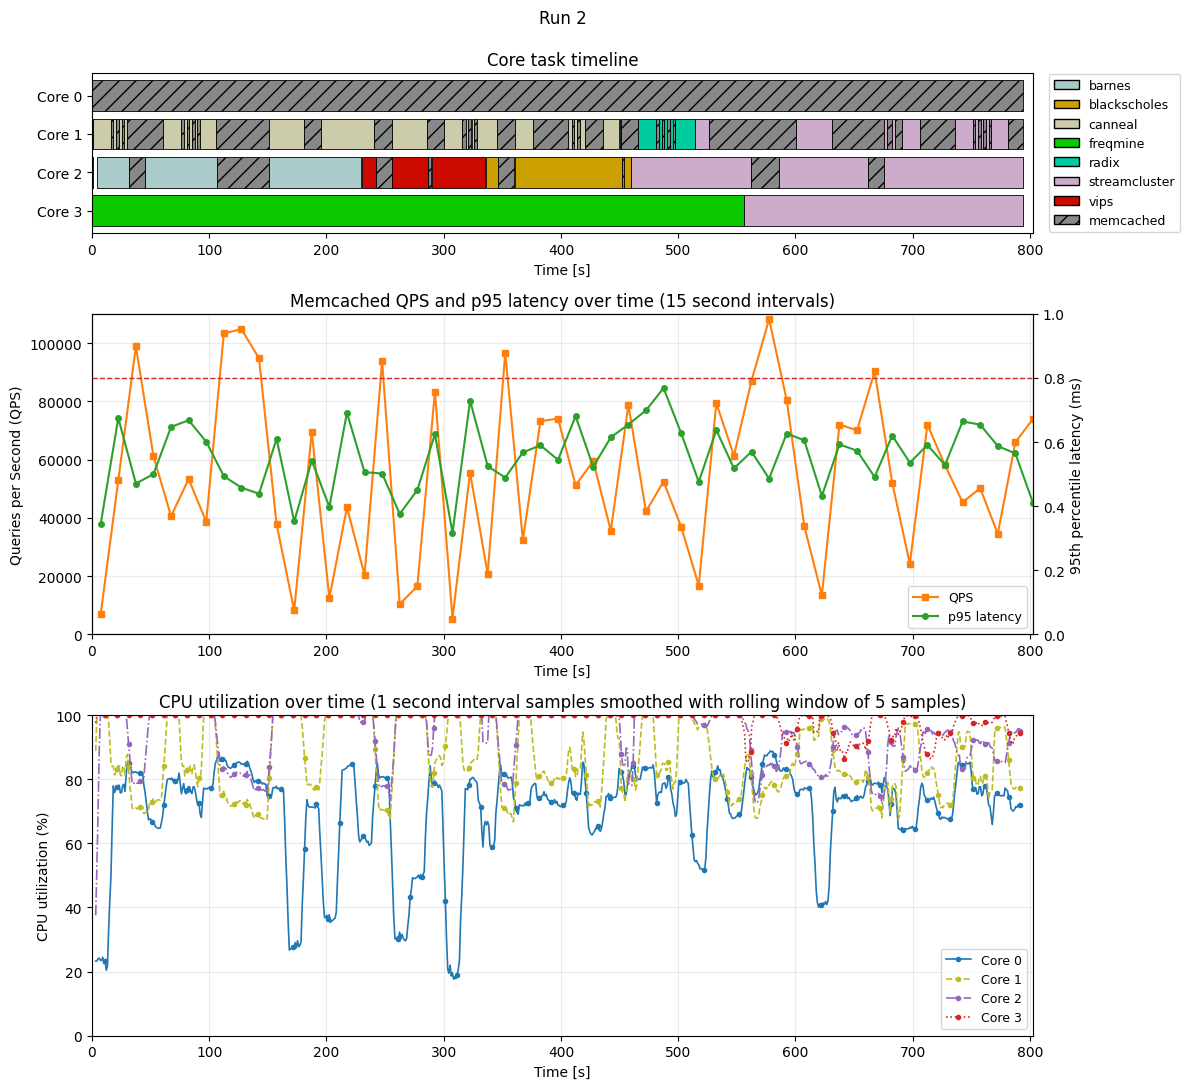

In [54]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 11), sharex=True, gridspec_kw={"height_ratios": [0.5, 1, 1]})

plot_core_utilization2(axes[0], segments, cores, DEFAULT_COLORS, show_idle=False, title=f"Run {run}\n\nCore task timeline")
plot_p95(axes[1], mcperf)
plot_cpu(axes[2], cpu)

for ax in axes:
    ax.set_xlabel("Time [s]")
    ax.set_xlim(0, max(core_df["time_s"].max(), mcperf["time"].max(), cpu["time"].max()))
    ax.tick_params(axis="x", labelbottom=True)
plt.tight_layout()
plt.show()